In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import boxcox

def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean

def transform_skewed(df, cols, mild_skew=0.5, strong_skew=1.5):
    df_transformed = df.copy()
    for col in cols:
        # Shift to avoid zeros
        data = df_transformed[col] + 1 if (df_transformed[col] <= 0).any() else df_transformed[col]
        skew = data.skew()
        if abs(skew) < mild_skew:
            df_transformed[col] = data
        elif abs(skew) < strong_skew:
            df_transformed[col] = np.log(data)
        else:
            df_transformed[col], _ = boxcox(data)
    return df_transformed

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred)
    }
    
raw_data = pd.read_csv("diamonds.csv")
raw_data.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [3]:
#No missing values
raw_data.duplicated().sum()

np.int64(146)

In [4]:
#There are 146 duplicate rows
raw_data.drop_duplicates()
len(raw_data)

53940

In [5]:
#Convert 0s in x,y,z to nan
cols = ['x','y','z']
raw_data[cols] = raw_data[cols].where(raw_data[cols]>0, np.nan)
raw_data = raw_data.drop(columns=['table'])
raw_data.describe()

,carat,depth,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53932.000000,53933.000000,53920.000000
mean,0.797940,61.749405,3932.799722,5.732007,5.735270,3.540046
std,0.474011,1.432621,3989.439738,1.119670,1.140339,0.702530
min,0.200000,43.000000,326.000000,3.730000,3.680000,1.070000
25%,0.400000,61.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,18823.000000,10.740000,58.900000,31.800000


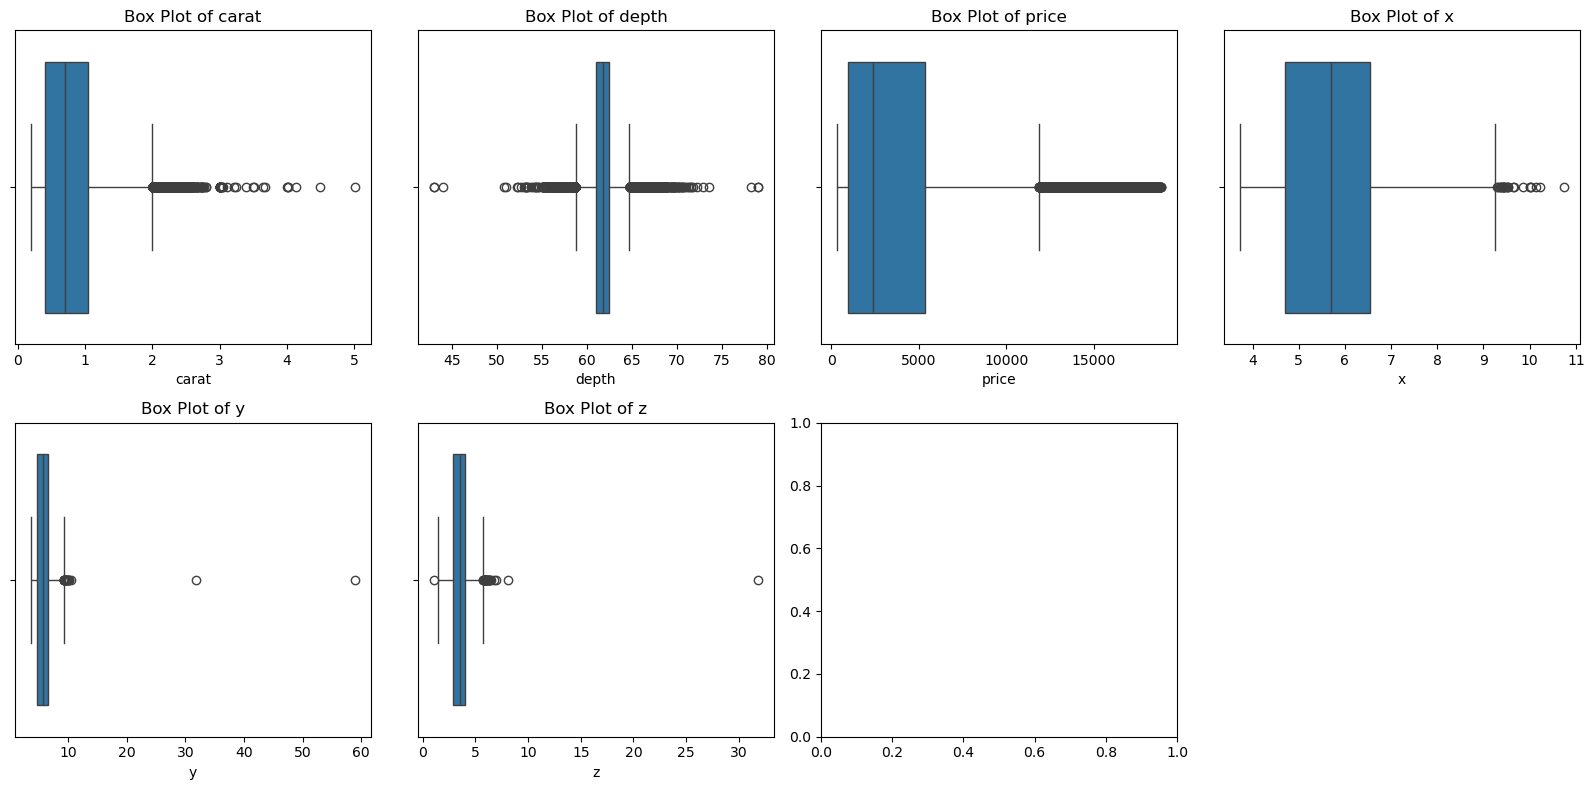

In [6]:
#Outlier Check using Boxplot
outlier_cols =['carat', 'depth', 'price', 'x', 'y', 'z']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(outlier_cols):
    sns.boxplot(x=raw_data[col], ax=axes[i])
    axes[i].set_title(f'Box Plot of {col}')

# Remove empty subplot (since 7 plots, 8 slots)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

In [7]:
#Outlier Handling IQR method
outlier_cols =['carat', 'depth', 'price', 'x', 'y', 'z']
filtered_df = remove_outliers_iqr(raw_data, outlier_cols)

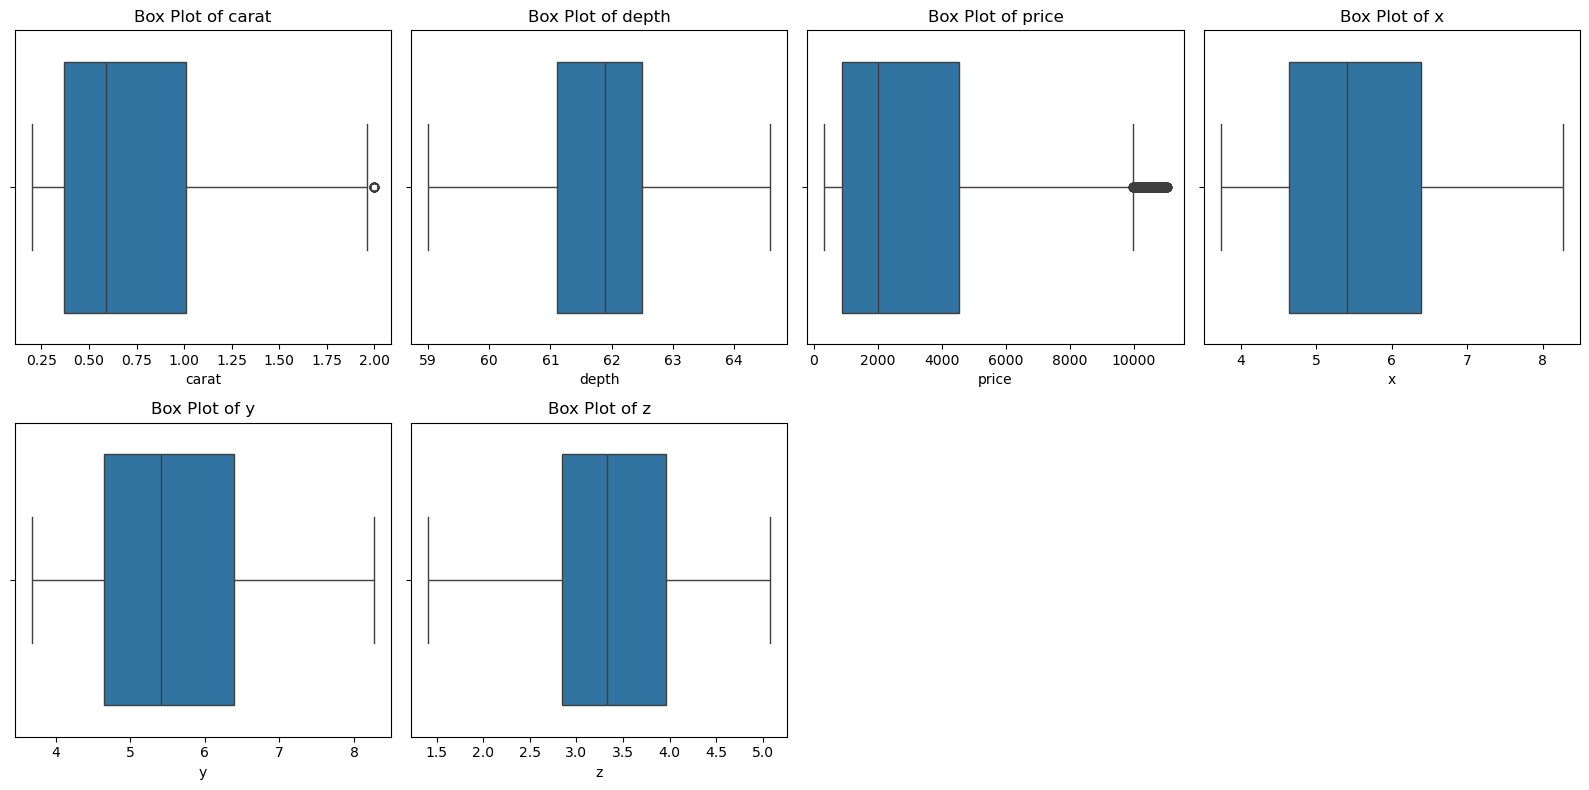

In [8]:
#Outlier Check using Boxplot After Outlier Handling
outlier_cols =['carat', 'depth', 'price', 'x', 'y', 'z']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(outlier_cols):
    sns.boxplot(x=filtered_df[col], ax=axes[i])
    axes[i].set_title(f'Box Plot of {col}')

# Remove empty subplot (since 7 plots, 8 slots)
fig.delaxes(axes[-1])
fig.delaxes(axes[-2])
plt.tight_layout()
plt.show()

In [9]:
#Skewness Handling
filtered_df[outlier_cols].skew()

carat    0.681054
depth   -0.198385
price    1.141442
x        0.250008
y        0.243792
z        0.245806
dtype: float64

In [10]:
transform_skewed(filtered_df, outlier_cols)
filtered_df[outlier_cols].skew()

carat    0.681054
depth   -0.198385
price    1.141442
x        0.250008
y        0.243792
z        0.245806
dtype: float64

**EDA**

__Distribution Plots__

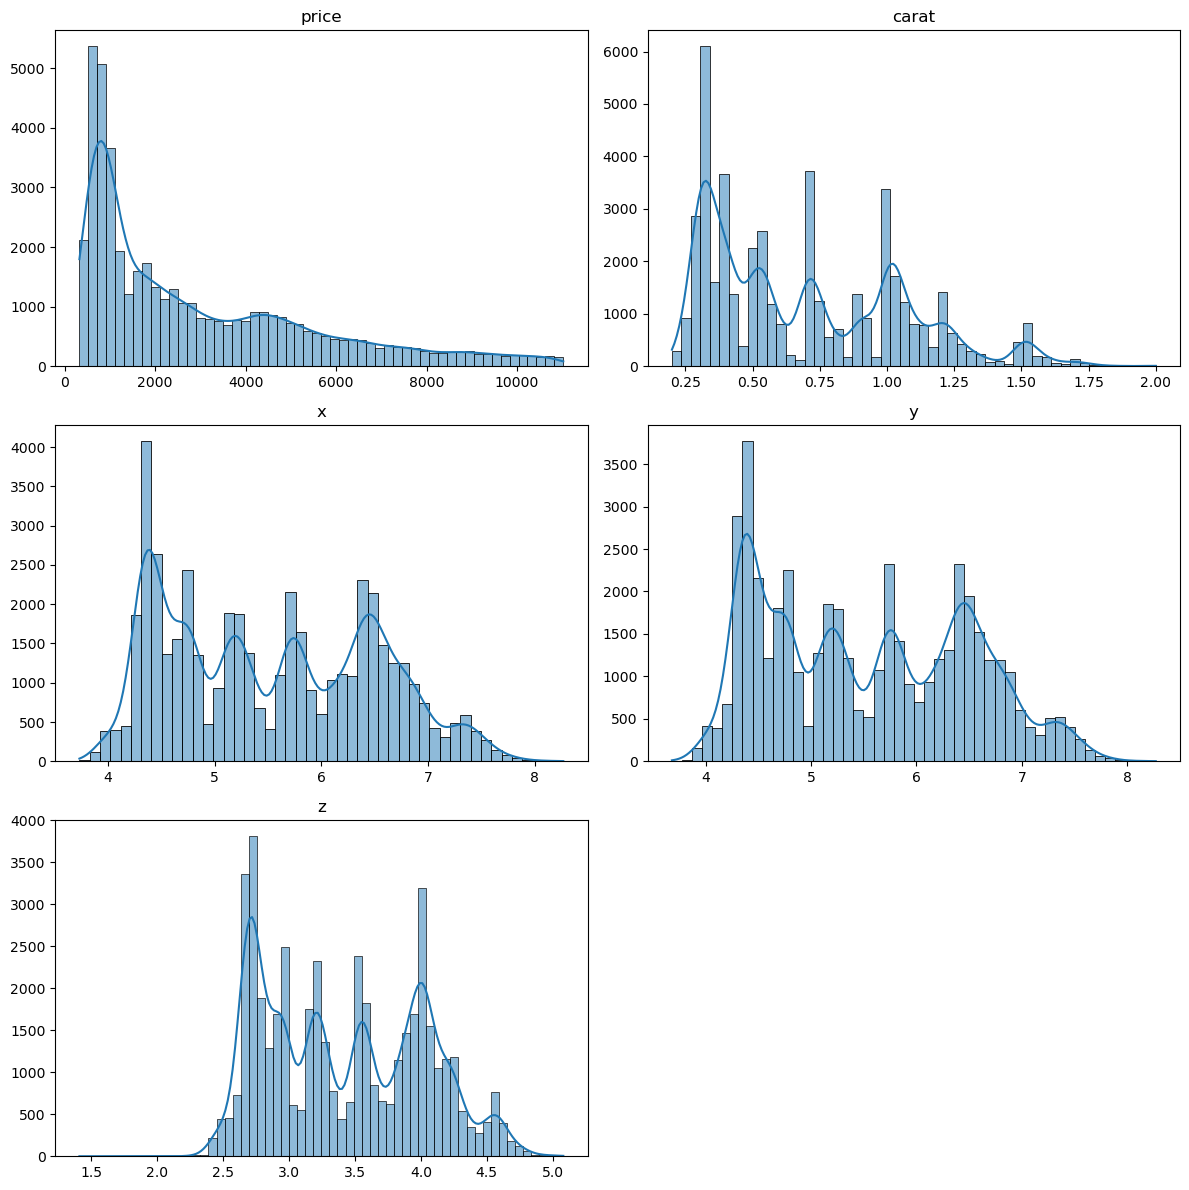

In [11]:
cols = ['price', 'carat', 'x', 'y', 'z']
fig, axes = plt.subplots(3, 2, figsize=(12, 12)) 
axes = axes.flatten()
for i, col in enumerate(cols):
    sns.histplot(filtered_df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

axes[len(cols)].axis('off') 
plt.tight_layout()
plt.show()

**Count Plots**

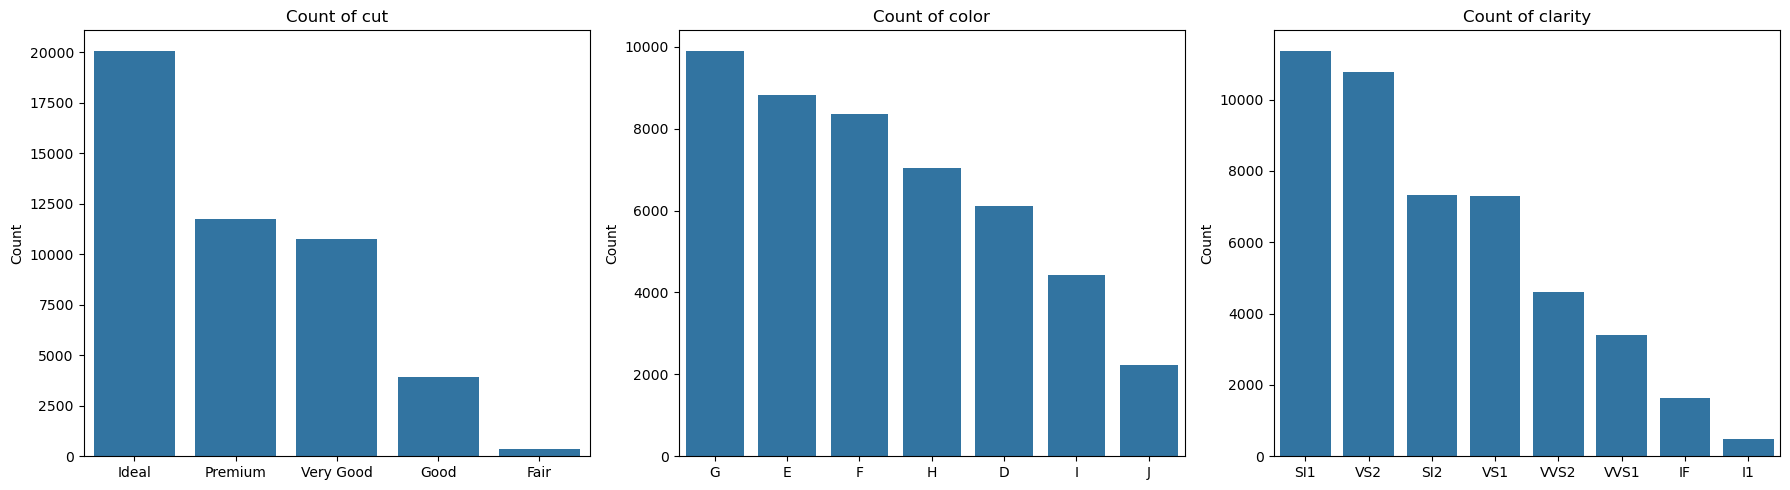

In [12]:
cat_cols = ['cut', 'color', 'clarity']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=filtered_df, ax=axes[i], order=filtered_df[col].value_counts().index)
    axes[i].set_title(f'Count of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Price Variation with Box Plots**

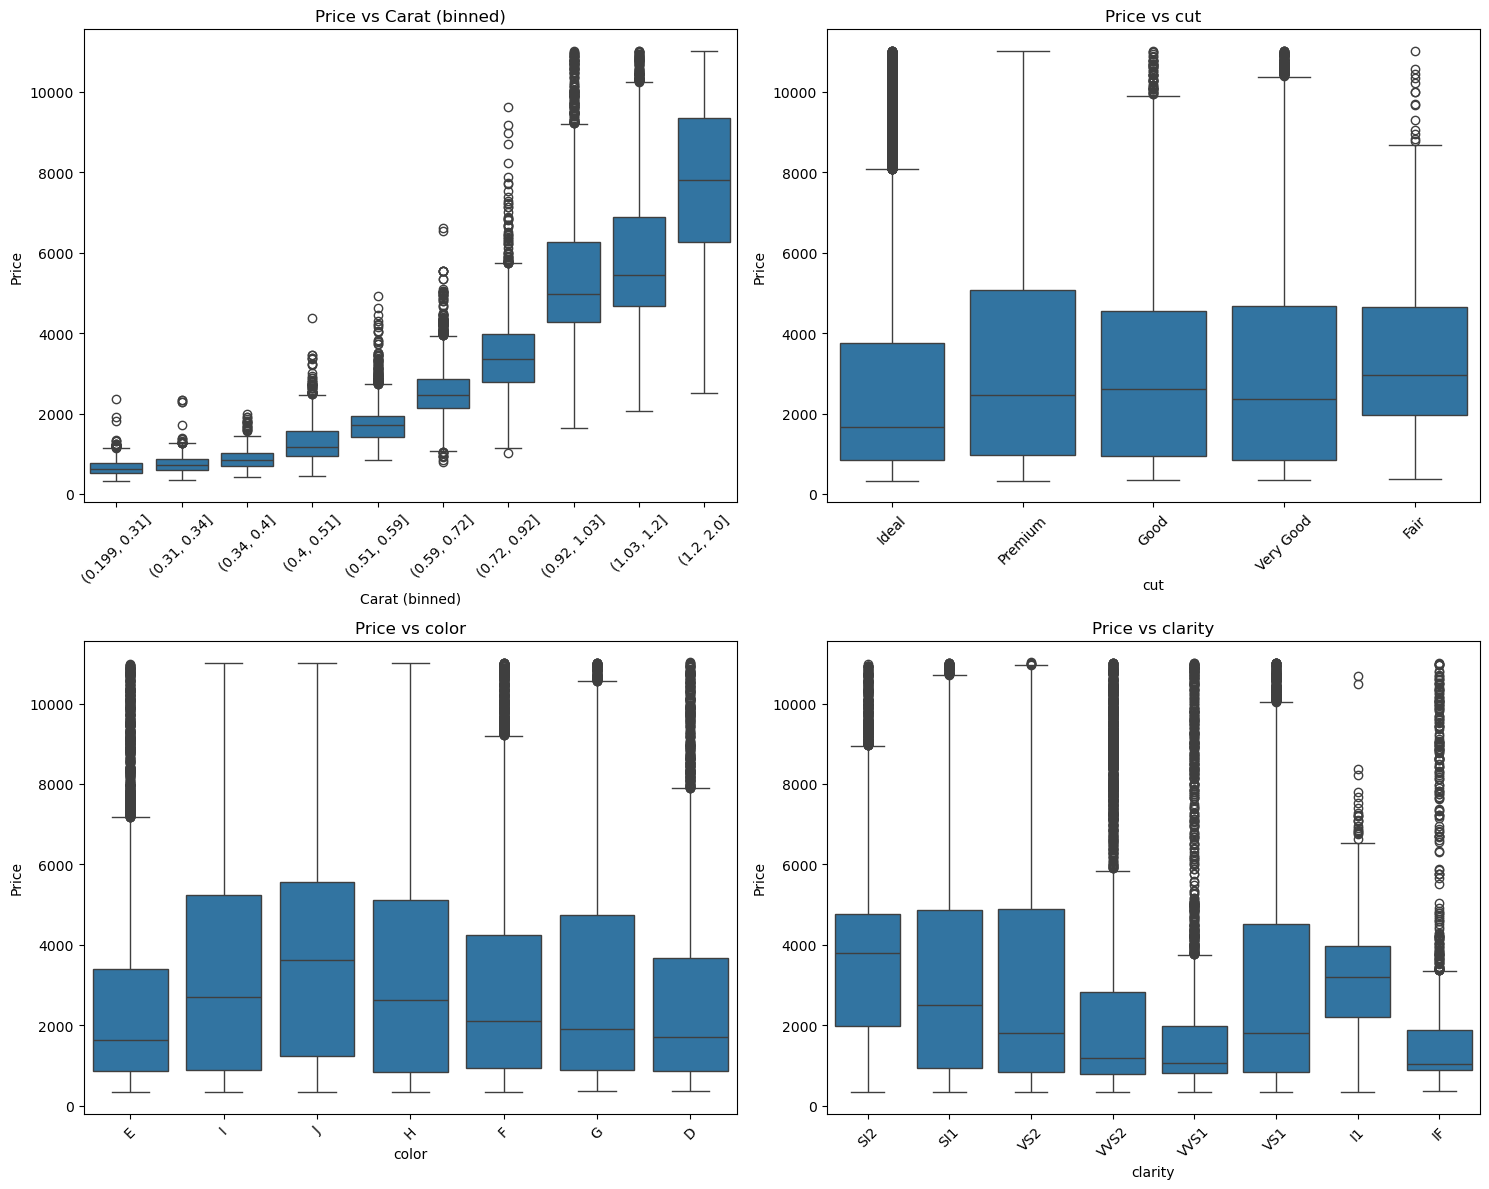

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

# Boxplot 1: Price vs Carat (continuous)
sns.boxplot(x=pd.qcut(filtered_df['carat'], 10), y='price', data=filtered_df, ax=axes[0])
axes[0].set_title('Price vs Carat (binned)')
axes[0].set_xlabel('Carat (binned)')
axes[0].set_ylabel('Price')
axes[0].tick_params(axis='x', rotation=45)

# Boxplots for categorical features
for i, col in enumerate(cat_cols):
    sns.boxplot(x=col, y='price', data=filtered_df, ax=axes[i+1])
    axes[i+1].set_title(f'Price vs {col}')
    axes[i+1].set_xlabel(col)
    axes[i+1].set_ylabel('Price')
    axes[i+1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Correlation Heat Map**

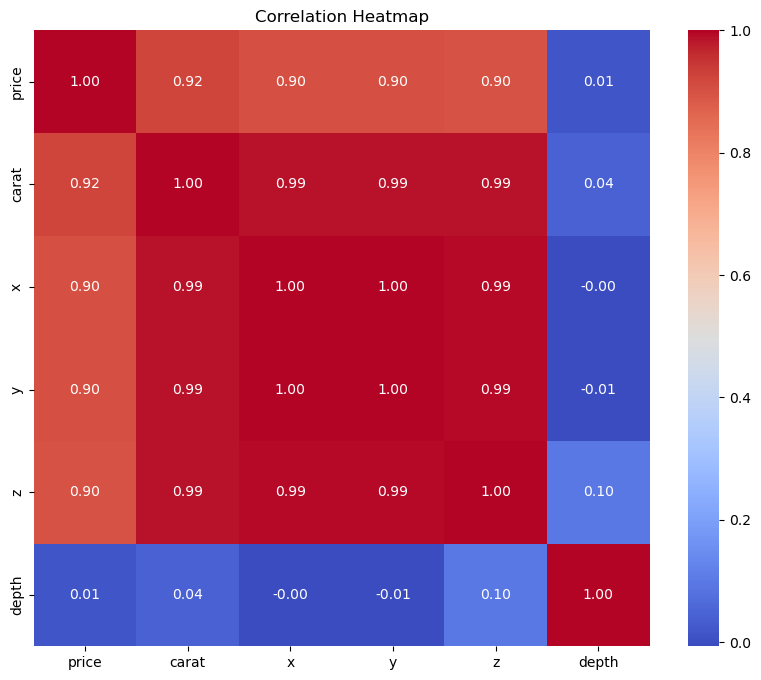

In [14]:
num_cols = ['price', 'carat', 'x', 'y', 'z', 'depth']
corr_matrix = filtered_df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.show()

**Scatter Plot**

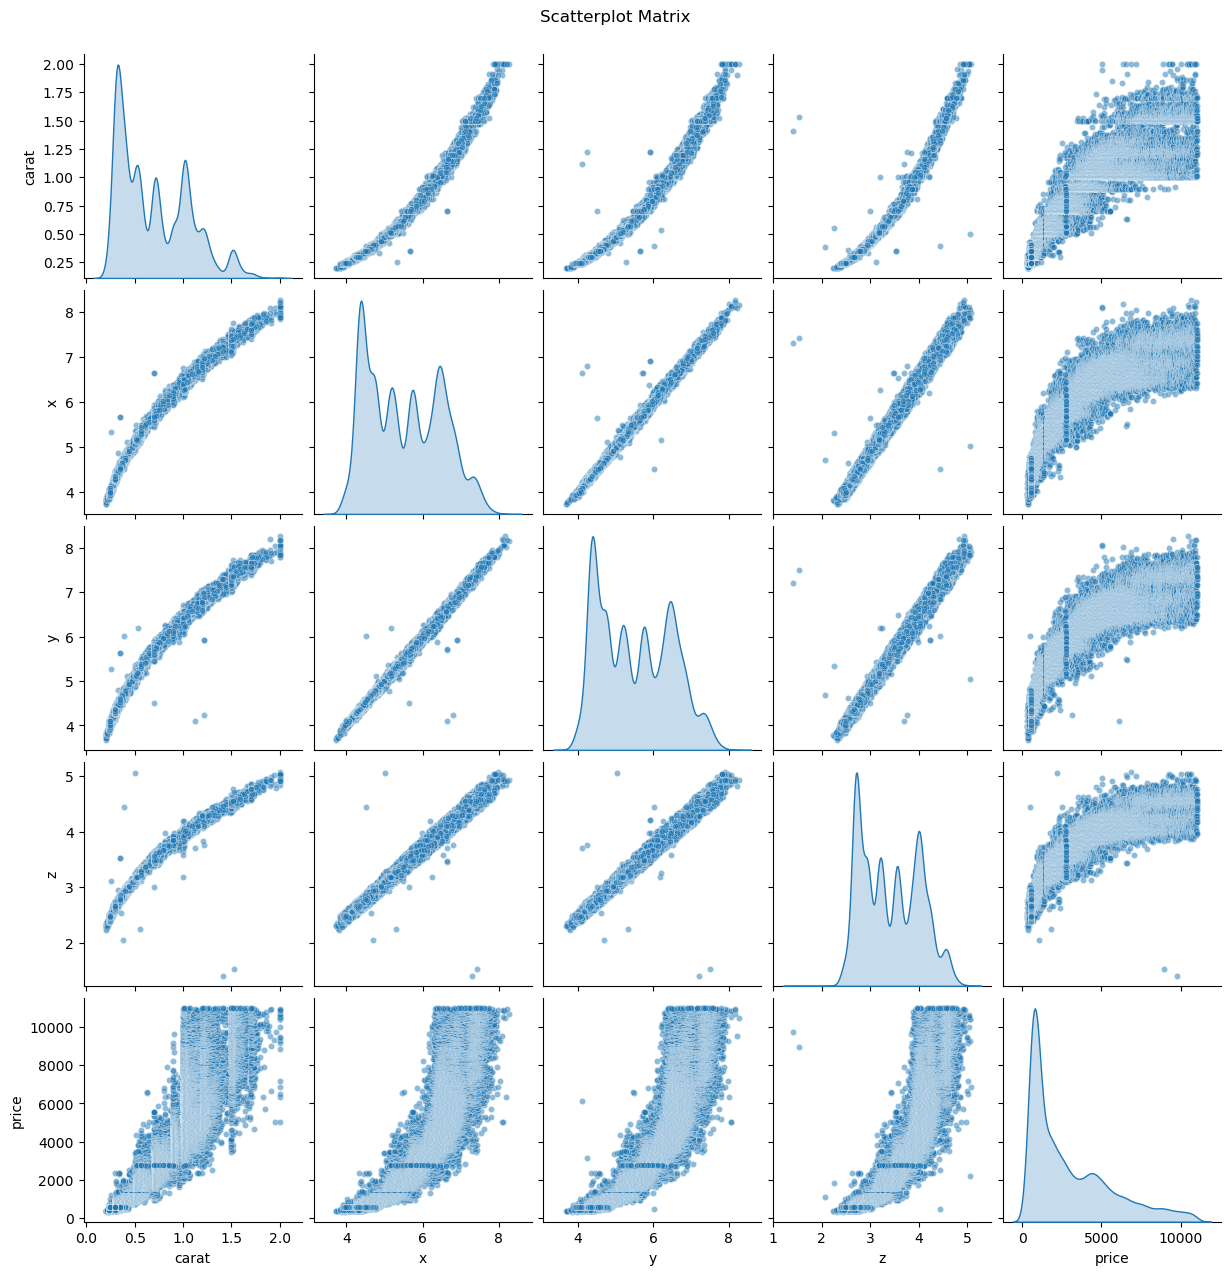

In [15]:
cols = ['carat', 'x', 'y', 'z', 'price']
sns.pairplot(filtered_df[cols], kind='scatter', diag_kind='kde', plot_kws={'alpha':0.5, 's':20})
plt.suptitle('Scatterplot Matrix', y=1.02)
plt.show()

**Regression Line Plot**

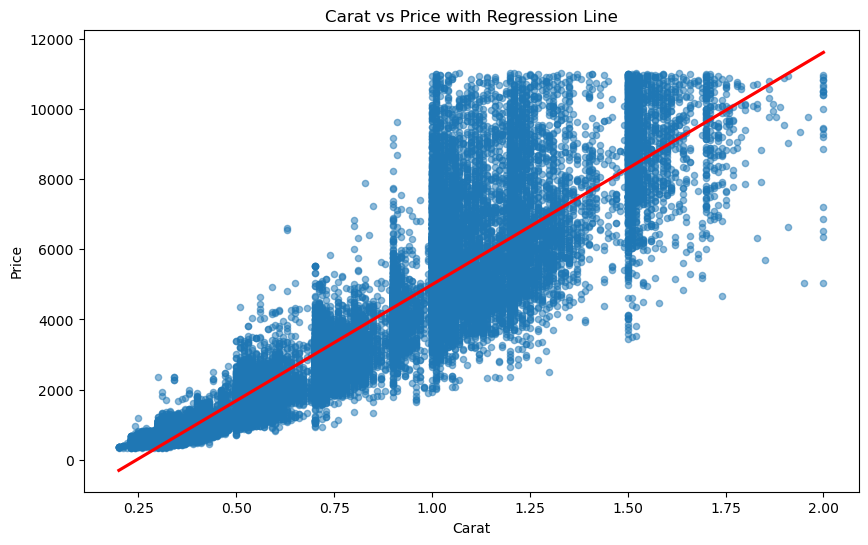

In [16]:
plt.figure(figsize=(10, 6))
sns.regplot(x='carat', y='price', data=filtered_df, scatter_kws={'alpha':0.5, 's':20}, line_kws={'color':'red'})
plt.title('Carat vs Price with Regression Line')
plt.xlabel('Carat')
plt.ylabel('Price')
plt.show()

**Average Price Per Categories Bar Plot**

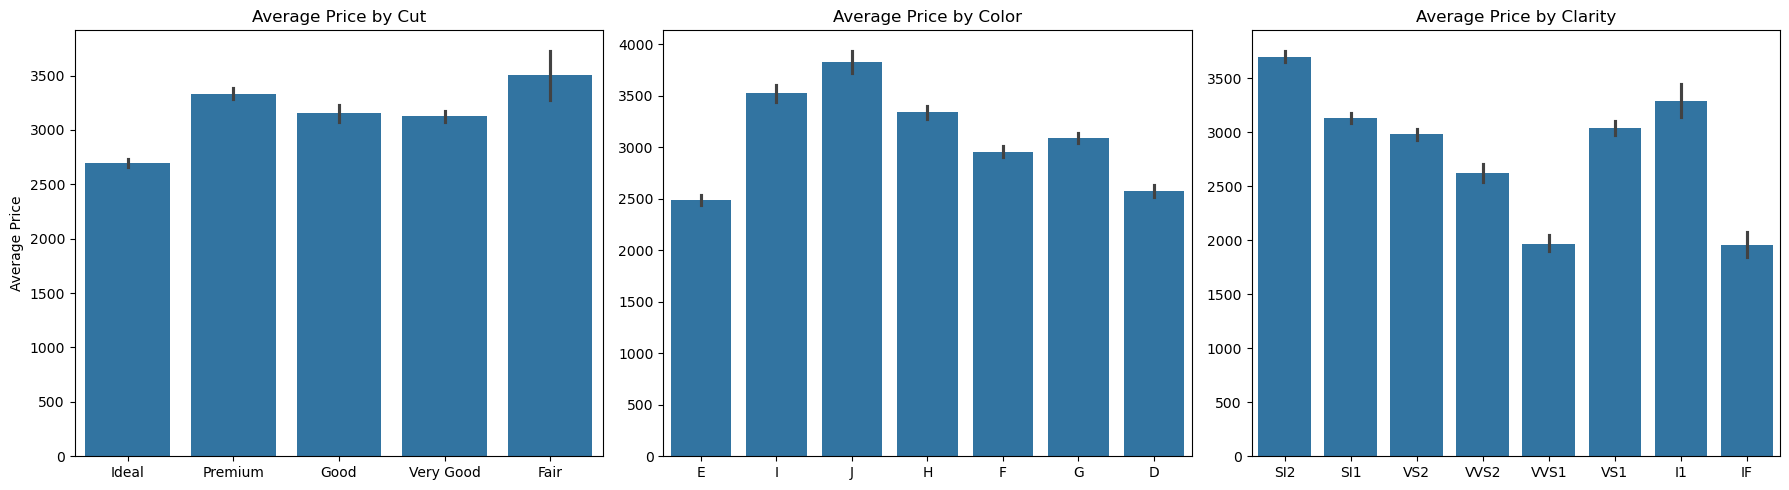

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x='cut', y='price', data=filtered_df, ax=axes[0])
axes[0].set_title('Average Price by Cut')
axes[0].set_xlabel('')
axes[0].set_ylabel('Average Price')

sns.barplot(x='color', y='price', data=filtered_df, ax=axes[1])
axes[1].set_title('Average Price by Color')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

sns.barplot(x='clarity', y='price', data=filtered_df, ax=axes[2])
axes[2].set_title('Average Price by Clarity')
axes[2].set_xlabel('')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

In [18]:
#Feature Engineering
filtered_df['volume'] = filtered_df['x'] * filtered_df['y'] * filtered_df['z']
filtered_df['price_per_carat_usd'] = filtered_df['price'] / filtered_df['carat']
USD_TO_INR = 83
filtered_df['price_inr'] = filtered_df['price'] * USD_TO_INR
filtered_df['price_per_carat_inr'] = filtered_df['price_per_carat_usd'] * USD_TO_INR
filtered_df['carat_category'] = pd.cut(
    filtered_df['carat'],
    bins=[0, 0.5, 1.5, float('inf')],
    labels=['Light', 'Medium', 'Heavy'],
    include_lowest=True
)

In [19]:
#Encoding
cut_map = {'Fair': 1, 'Good': 2, 'Very Good': 3, 'Premium': 4, 'Ideal': 5}
color_map = {'J': 1, 'I': 2, 'H': 3, 'G': 4, 'F': 5, 'E': 6, 'D': 7}
clarity_map = {'I1': 1, 'SI2': 2, 'SI1': 3, 'VS2': 4, 'VS1': 5,
               'VVS2': 6, 'VVS1': 7, 'IF': 8}
carat_cat_map = {'Light': 1, 'Medium': 2, 'Heavy': 3}
filtered_df['cut_ord'] = filtered_df['cut'].map(cut_map)
filtered_df['color_ord'] = filtered_df['color'].map(color_map)
filtered_df['clarity_ord'] = filtered_df['clarity'].map(clarity_map)
filtered_df['carat_category_ord'] = filtered_df['carat_category'].map(carat_cat_map).astype(int)

In [20]:
features = [
    'clarity_ord',         
    'color_ord',
    'cut_ord', 
    'carat_category_ord',
    'price_per_carat_inr',
    'volume',
    'carat',
    'depth'
]

y = filtered_df['price_inr']
X = filtered_df[features]


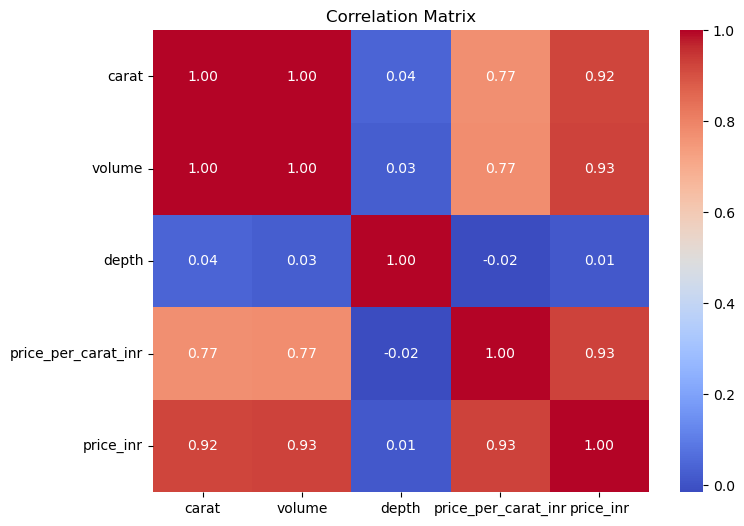

In [21]:
#Feature Selection using Correlation Matrix
numeric_features = ['carat','volume','depth','price_per_carat_inr','price_inr']
corr_matrix = filtered_df[numeric_features].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [22]:
#Feature Selection using VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()
vif['feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif

,feature,VIF
0,clarity_ord,15.885443
1,color_ord,12.682703
2,cut_ord,17.859765
3,carat_category_ord,34.138222
4,price_per_carat_inr,32.467960
5,volume,2536.049325
6,carat,2500.896836
7,depth,67.780786


In [23]:
#Feature selection using RFE
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

X = filtered_df[features]
y = filtered_df['price_inr']
estimator = LinearRegression()
rfe = RFE(estimator=estimator, n_features_to_select=5)
rfe.fit(X, y)
selected_features = X.columns[rfe.support_]
print("Selected features:", list(selected_features))
feature_ranking = pd.Series(rfe.ranking_, index=X.columns).sort_values()
print(feature_ranking)


Selected features: ['clarity_ord', 'color_ord', 'cut_ord', 'carat_category_ord', 'carat']
clarity_ord            1
color_ord              1
cut_ord                1
carat_category_ord     1
carat                  1
volume                 2
depth                  3
price_per_carat_inr    4
dtype: int64


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor


X = filtered_df[selected_features]
y = filtered_df['price_inr']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_metrics = evaluate_model(lr, X_test, y_test)

dt = DecisionTreeRegressor(max_depth=8, random_state=42)
dt.fit(X_train, y_train)
dt_metrics = evaluate_model(dt, X_test, y_test)

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_metrics = evaluate_model(rf, X_test, y_test)

knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=7))
])
knn_pipeline.fit(X_train, y_train)
knn_metrics = evaluate_model(knn_pipeline, X_test, y_test)

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)
xgb_metrics = evaluate_model(xgb, X_test, y_test)

In [26]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ann = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

ann.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
ann.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

ann.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

D:\Reneta_AI_ML\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
ann_pred = ann.predict(X_test_scaled).flatten()

ann_metrics = {
    "MAE": mean_absolute_error(y_test, ann_pred),
    "MSE": mean_squared_error(y_test, ann_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, ann_pred)),
    "R2": r2_score(y_test, ann_pred)
}

results = pd.DataFrame({
    "Linear Regression": lr_metrics,
    "Decision Tree": dt_metrics,
    "Random Forest": rf_metrics,
    "KNN": knn_metrics,
    "XGBoost": xgb_metrics,
    "ANN": ann_metrics
}).T
results.sort_values(by="RMSE")

293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


,MAE,MSE,RMSE,R2
XGBoost,16590.787109,8.551002e+08,29242.095684,0.981403
Random Forest,17595.762028,9.271954e+08,30449.883816,0.979835
KNN,19050.111362,1.140988e+09,33778.520895,0.975185
Decision Tree,21962.927585,1.327747e+09,36438.264582,0.971124
ANN,27405.955078,2.157273e+09,46446.448476,0.953083
Linear Regression,44086.549077,3.907649e+09,62511.191291,0.915015


In [28]:
import joblib

joblib.dump(xgb, "diamond_price_xgboost.pkl")
joblib.dump(features, "model_features.pkl")

['model_features.pkl']

In [37]:
#Clustering
from sklearn.cluster import KMeans
cluster_features = [
    'carat',
    'cut_ord',
    'color_ord',
    'clarity_ord',
    'carat_category_ord'
]

X_cluster = filtered_df[cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

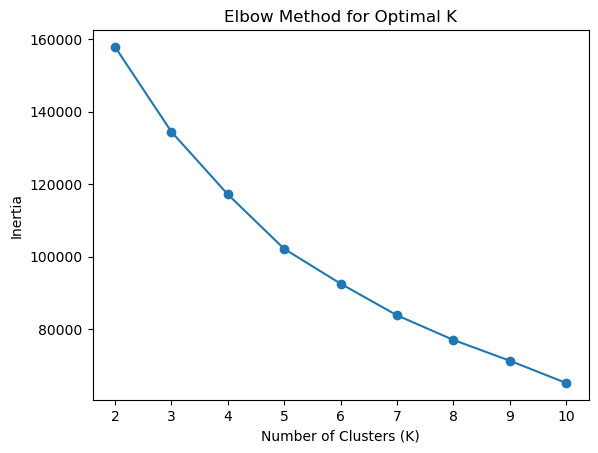

In [38]:
inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

In [39]:
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, Silhouette Score={score:.3f}")

K=2, Silhouette Score=0.309
K=3, Silhouette Score=0.249
K=4, Silhouette Score=0.228
K=5, Silhouette Score=0.239
K=6, Silhouette Score=0.243
K=7, Silhouette Score=0.249


In [40]:
kmeans_final = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X_scaled)

filtered_df['cluster'] = cluster_labels
filtered_df.groupby('cluster')[cluster_features].mean()

,carat,cut_ord,color_ord,clarity_ord,carat_category_ord
cluster,,,,,
0,0.815861,3.871092,5.664954,3.422984,2.011920
1,1.086084,3.851009,2.778837,3.506008,2.114547
2,0.405263,4.522678,4.046544,6.454320,1.211987
3,0.359743,3.935315,5.191441,3.754685,1.000000


In [41]:
cluster_names = {
    0: "Clarity-Focused Budget",
    1: "Size-Driven Premium",
    2: "Color-Priority Value",
    3: "Balanced Premium Quality"
}

filtered_df['cluster_name'] = filtered_df['cluster'].map(cluster_names)

In [42]:
joblib.dump(scaler, "diamond_cluster_scaler.pkl")
joblib.dump(kmeans_final, "diamond_kmeans.pkl")
joblib.dump(cluster_names, "diamond_cluster_names.pkl")

['diamond_cluster_names.pkl']

In [43]:
#PCA
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

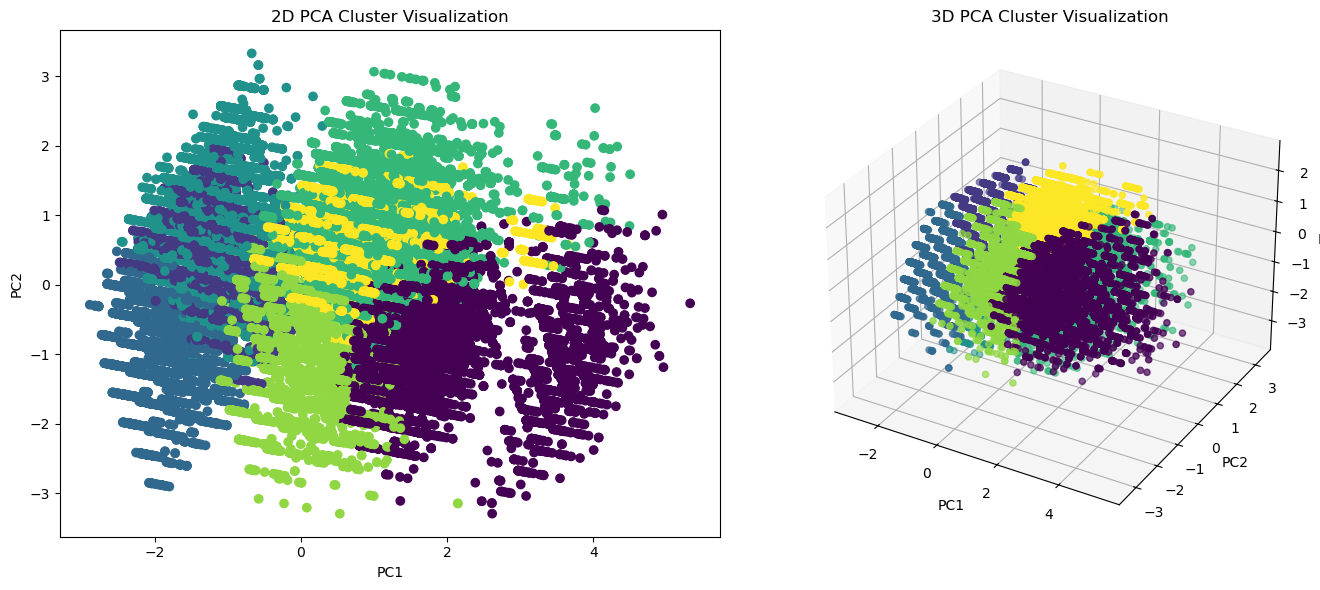

In [44]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 6))

# ---- 2D PCA subplot ----
ax1 = fig.add_subplot(1, 2, 1)
scatter1 = ax1.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=labels
)
ax1.set_title("2D PCA Cluster Visualization")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")

# ---- 3D PCA subplot ----
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
scatter2 = ax2.scatter(
    X_pca_3d[:, 0],
    X_pca_3d[:, 1],
    X_pca_3d[:, 2],
    c=labels
)
ax2.set_title("3D PCA Cluster Visualization")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_zlabel("PC3")

plt.tight_layout()
plt.show()